In [4]:
# ============================================================
# ADDA
# ============================================================

import sys
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.utils import to_categorical
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from adapt.feature_based import ADDA
import matplotlib.pyplot as plt

sys.path.append(r"D:\Woodchip_moisture_content\Dataset")
from dataset_2_1 import SourceDataset, TargetDataset, WoodChipTargetEvalDataset

# ============================================================
# 1. Settings
# ============================================================
SEED        = 42
NUM_CLASSES = 3
IMG_HEIGHT  = 224
IMG_WIDTH   = 224
CHANNELS    = 3
SAVE_DIR    = r"D:\Woodchip_moisture_content\Adapt_codes\ADDA\ADDA_2_1"
os.makedirs(SAVE_DIR, exist_ok=True)

np.random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================
# 2. Load Data
# ============================================================
def dataset_to_numpy(dataset_2_1, has_labels=True):
    loader = DataLoader(dataset_2_1, batch_size=32, shuffle=False, num_workers=0)
    X_list, y_list = [], []
    for batch in loader:
        if has_labels:
            imgs, labels = batch
            y_list.append(labels.numpy())
        else:
            imgs = batch
        X_list.append(imgs.permute(0, 2, 3, 1).numpy())
    X = np.concatenate(X_list, axis=0).astype(np.float32)
    if has_labels:
        return X, np.concatenate(y_list, axis=0)
    return X

print("Loading data...")
Xs, ys_int      = dataset_to_numpy(SourceDataset())
Xt              = dataset_to_numpy(TargetDataset(), has_labels=False)
Xt_eval, yt_int = dataset_to_numpy(WoodChipTargetEvalDataset())
print(f"Source: {Xs.shape} | Target: {Xt_eval.shape}")

# ============================================================
# 3. Train / Validation / Test Splits
# ============================================================
ys = to_categorical(ys_int, num_classes=NUM_CLASSES)

Xs_train, Xs_val, ys_train, ys_val, ys_train_int, ys_val_int = train_test_split(
    Xs, ys, ys_int, test_size=0.2, random_state=SEED, stratify=ys_int
)
Xt_train, Xt_test, _, yt_test_int = train_test_split(
    Xt_eval, yt_int, test_size=0.2, random_state=SEED, stratify=yt_int
)

print(f"Xs_train: {Xs_train.shape} | Xs_val: {Xs_val.shape}")
print(f"Xt_train: {Xt_train.shape} | Xt_test: {Xt_test.shape}")

# ============================================================
# 4. Build Encoder, Classifier, Discriminator
# ============================================================
def build_encoder(input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)):
    base = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    # Unfreeze only the last 20 layers
    base.trainable = True
    for layer in base.layers[:-20]:
        layer.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = base(inputs, training=True)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    return Model(inputs, x, name="encoder")

def build_task_classifier(feature_dim=128, num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=(feature_dim,))
    x = layers.Dense(64, activation="relu")(inputs)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inputs, outputs, name="task_classifier")

def build_discriminator(feature_dim=128):
    inputs = layers.Input(shape=(feature_dim,))
    x = layers.Dense(64, activation="relu")(inputs)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    return Model(inputs, outputs, name="discriminator")

encoder       = build_encoder()
task          = build_task_classifier()
discriminator = build_discriminator()

# ============================================================
# 5. Train ADDA
# ============================================================
adda = ADDA(
    encoder=encoder,
    task=task,
    discriminator=discriminator,
    Xt=Xt_train,
    pretrain=True,
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    optimizer_enc=tf.keras.optimizers.Adam(learning_rate=1e-5),
    optimizer_disc=tf.keras.optimizers.Adam(learning_rate=1e-4),
    metrics=["accuracy"],
    batch_size=16,
    epochs=100,
    verbose=1,
    random_state=SEED,
    run_eagerly=True
)

print("\nTraining ADDA ...")
adda.fit(Xs_train, ys_train)

# ============================================================
# 6. Predictions
# ============================================================
val_preds     = np.argmax(adda.predict(Xs_val), axis=1)
tgt_preds     = np.argmax(adda.predict(Xt_test), axis=1)
src_probs_vis = adda.predict(Xs)
src_preds_vis = np.argmax(src_probs_vis, axis=1)
tgt_probs_vis = adda.predict(Xt_eval)
tgt_preds_vis = np.argmax(tgt_probs_vis, axis=1)

# ============================================================
# 7. Classification Reports
# ============================================================
print("\nClassification Report (Source Validation):")
print(classification_report(ys_val_int, val_preds, target_names=['Dry', 'Medium', 'Wet']))

print("Classification Report (Target Test):")
print(classification_report(yt_test_int, tgt_preds, target_names=['Dry', 'Medium', 'Wet']))

# ============================================================
# 8. Metrics Summary
# ============================================================
src_acc       = accuracy_score(ys_val_int, val_preds)
src_precision = precision_score(ys_val_int, val_preds, average='weighted')
src_recall    = recall_score(ys_val_int, val_preds, average='weighted')
src_f1        = f1_score(ys_val_int, val_preds, average='weighted')

tgt_acc       = accuracy_score(yt_test_int, tgt_preds)
tgt_precision = precision_score(yt_test_int, tgt_preds, average='weighted')
tgt_recall    = recall_score(yt_test_int, tgt_preds, average='weighted')
tgt_f1        = f1_score(yt_test_int, tgt_preds, average='weighted')

print("\nMETRICS SUMMARY")
print("=" * 50)
print(f"{'Metric':<16} {'Source':>10} {'Target':>10}")
print("-" * 50)
print(f"{'Accuracy':<16} {src_acc:>10.3f} {tgt_acc:>10.3f}")
print(f"{'Precision':<16} {src_precision:>10.3f} {tgt_precision:>10.3f}")
print(f"{'Recall':<16} {src_recall:>10.3f} {tgt_recall:>10.3f}")
print(f"{'F1':<16} {src_f1:>10.3f} {tgt_f1:>10.3f}")
print("=" * 50)

# ============================================================
# 9. Save Outputs
# ============================================================
np.save(os.path.join(SAVE_DIR, "Xs.npy"),            Xs)
np.save(os.path.join(SAVE_DIR, "ys_int.npy"),        ys_int)
np.save(os.path.join(SAVE_DIR, "Xt_eval.npy"),       Xt_eval)
np.save(os.path.join(SAVE_DIR, "yt_int.npy"),        yt_int)
np.save(os.path.join(SAVE_DIR, "ys_val_int.npy"),    ys_val_int)
np.save(os.path.join(SAVE_DIR, "val_preds.npy"),     val_preds)
np.save(os.path.join(SAVE_DIR, "yt_test_int.npy"),   yt_test_int)
np.save(os.path.join(SAVE_DIR, "tgt_preds.npy"),     tgt_preds)
np.save(os.path.join(SAVE_DIR, "src_probs_vis.npy"), src_probs_vis)
np.save(os.path.join(SAVE_DIR, "src_preds_vis.npy"), src_preds_vis)
np.save(os.path.join(SAVE_DIR, "tgt_probs_vis.npy"), tgt_probs_vis)
np.save(os.path.join(SAVE_DIR, "tgt_preds_vis.npy"), tgt_preds_vis)
print(f"\nAll outputs saved to: {SAVE_DIR}")

Loading data...
Source: (800, 224, 224, 3) | Target: (800, 224, 224, 3)
Xs_train: (640, 224, 224, 3) | Xs_val: (160, 224, 224, 3)
Xt_train: (640, 224, 224, 3) | Xt_test: (160, 224, 224, 3)

Training ADDA ...
Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - acc: 0.0000e+00 - accuracy: 0.4219 - loss: 0.3480
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - acc: 0.0000e+00 - accuracy: 0.5656 - loss: 0.3933
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - acc: 0.0000e+00 - accuracy: 0.6766 - loss: 0.4376
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - acc: 0.0000e+00 - accuracy: 0.7922 - loss: 0.4988
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - acc: 0.0000e+00 - accuracy: 0.8484 - loss: 0.5526
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - acc: 0.0000e+00 - accuracy: 0.8609 - loss: 0.6166
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - acc: 0.0000e+00 - accuracy: 0.8734 - loss: 0.6605
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - acc: 0.00

Outputs loaded successfully.


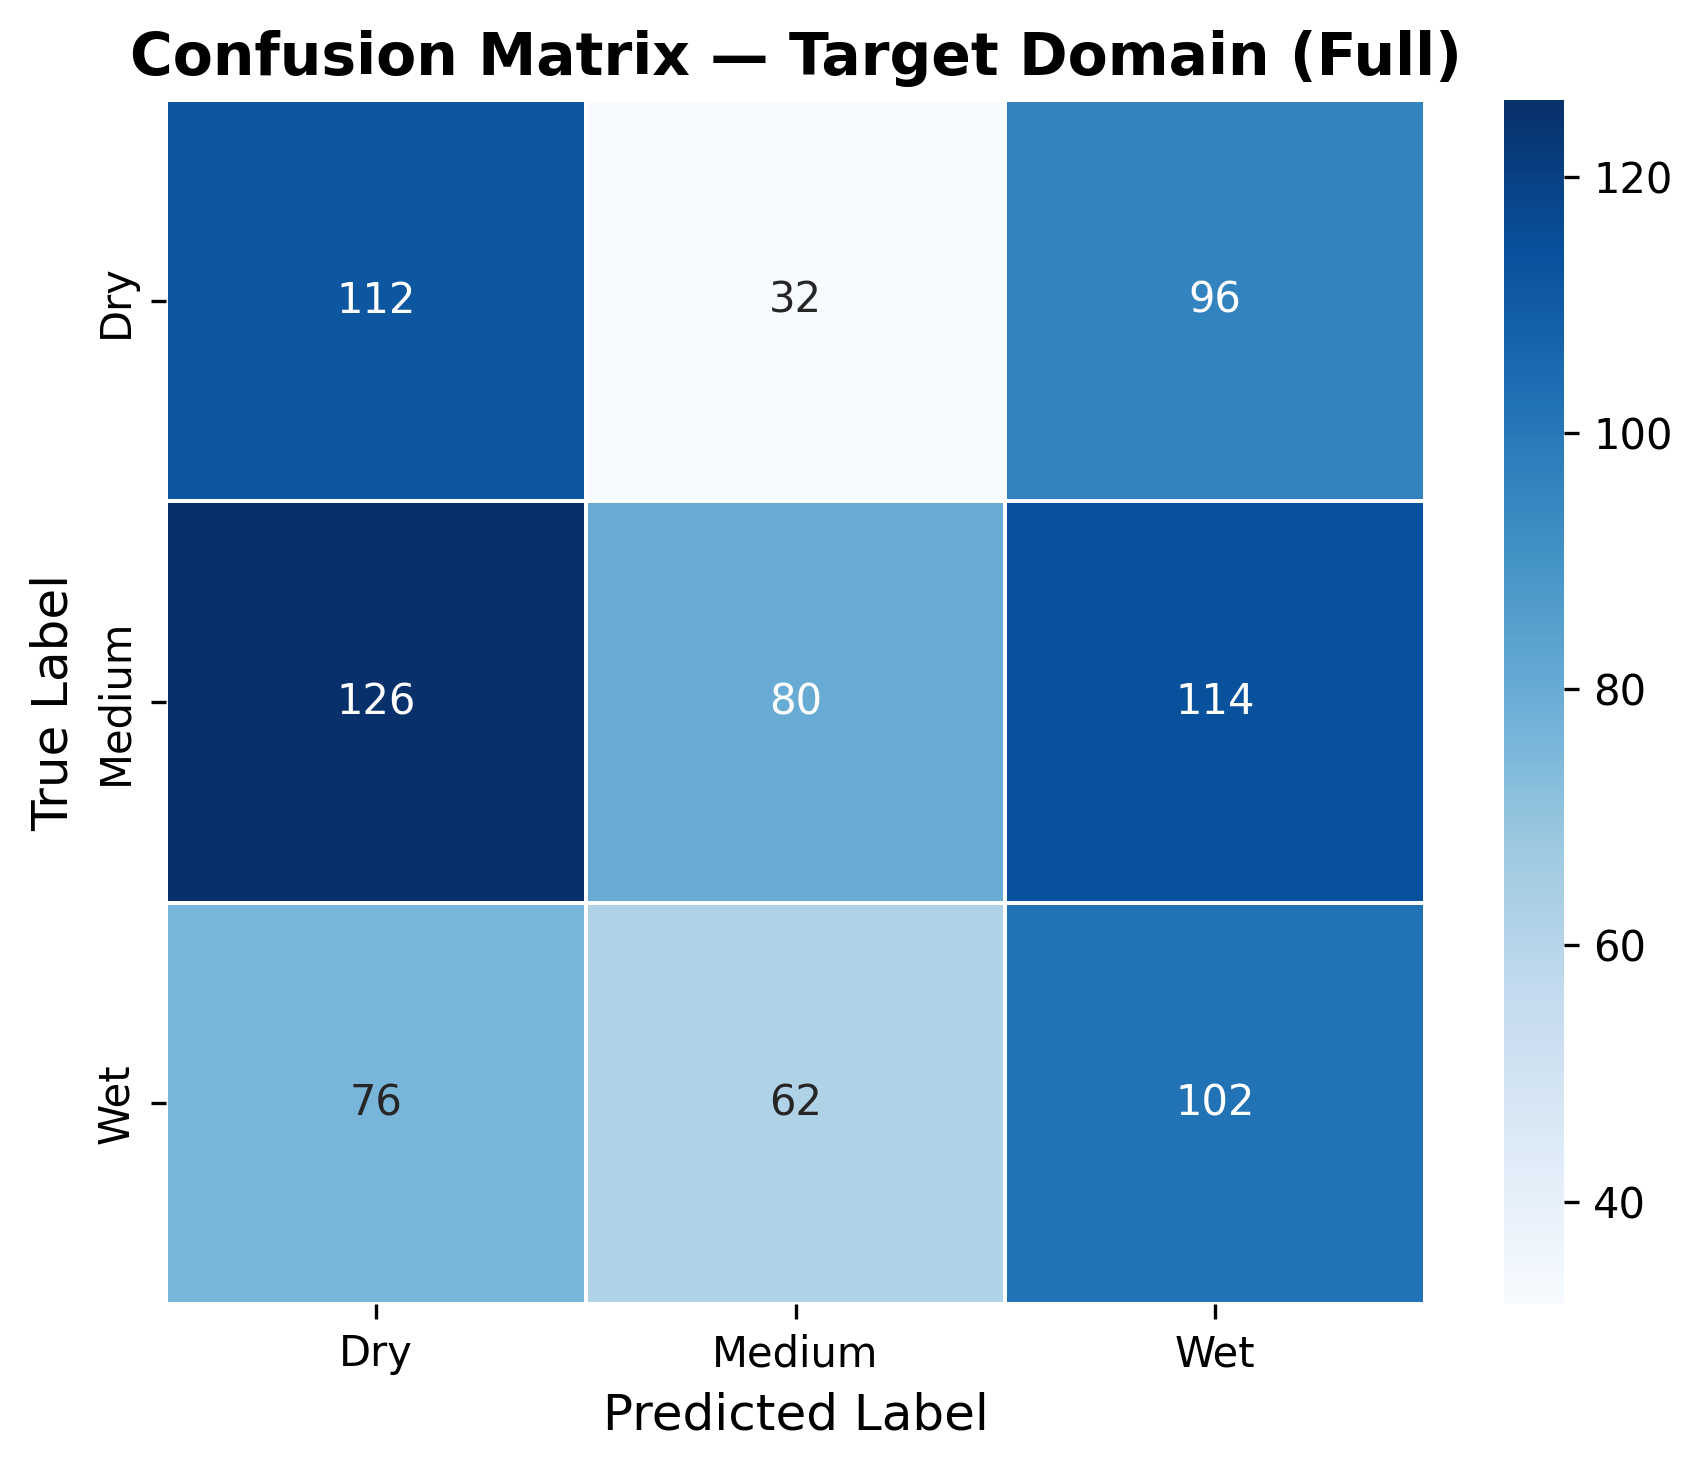

Saved: D:\Woodchip_moisture_content\Adapt_codes\ADDA\ADDA_2_1\confusion_matrix_target_full.jpg

Visualizing predictions on SOURCE domain samples:


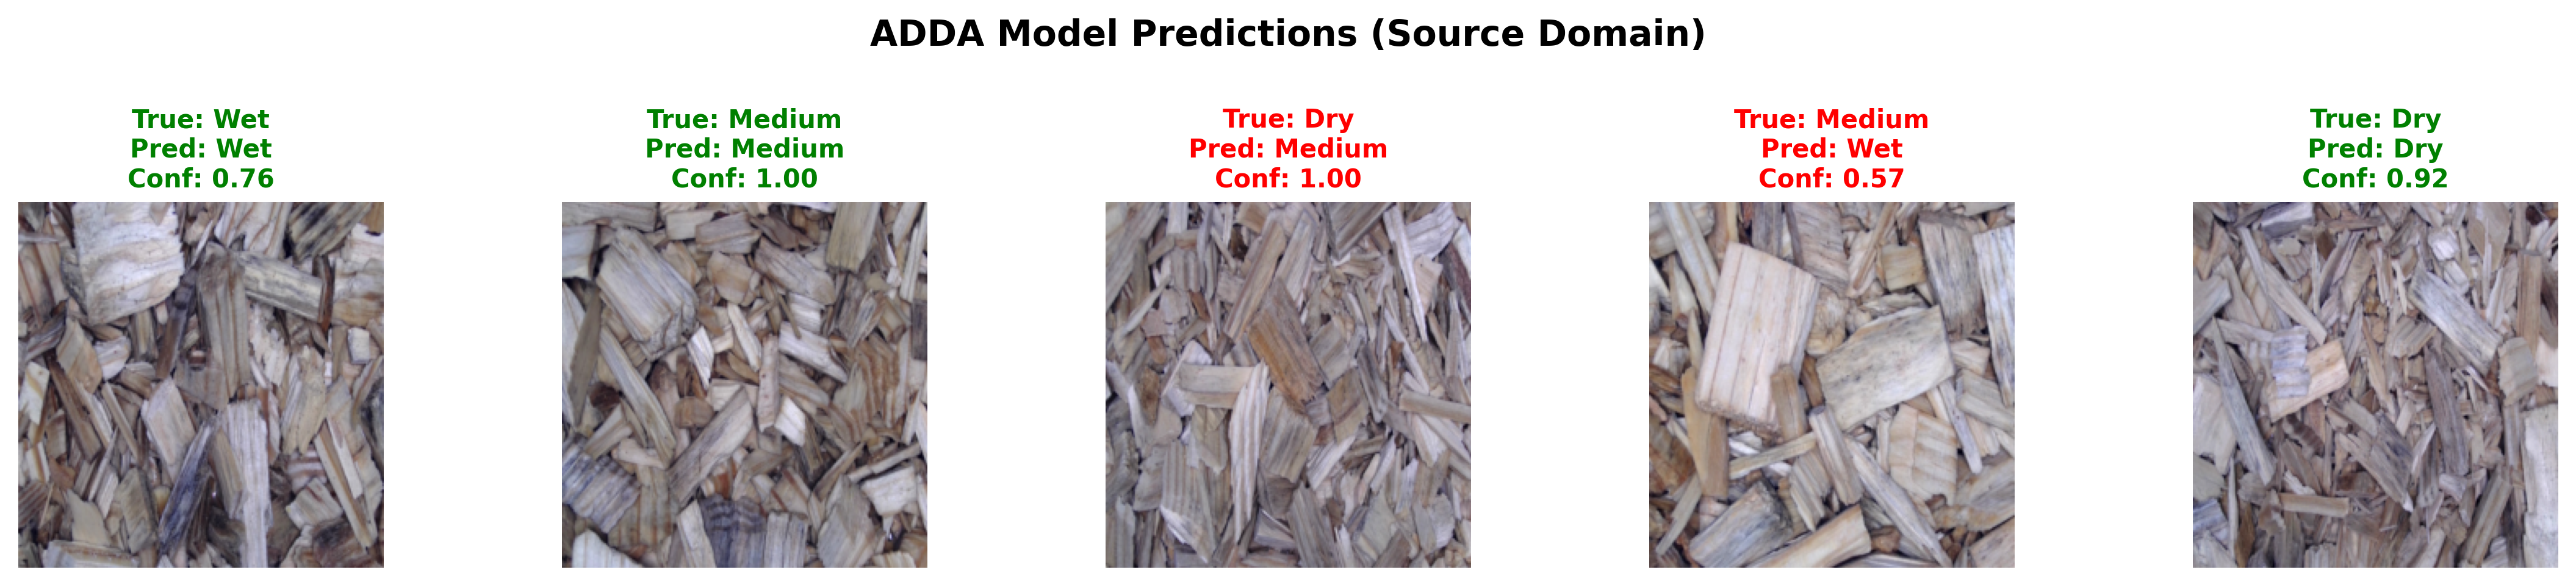

Saved: D:\Woodchip_moisture_content\Adapt_codes\ADDA\ADDA_2_1\source_predictions_grid.jpg

Visualizing predictions on TARGET domain samples:


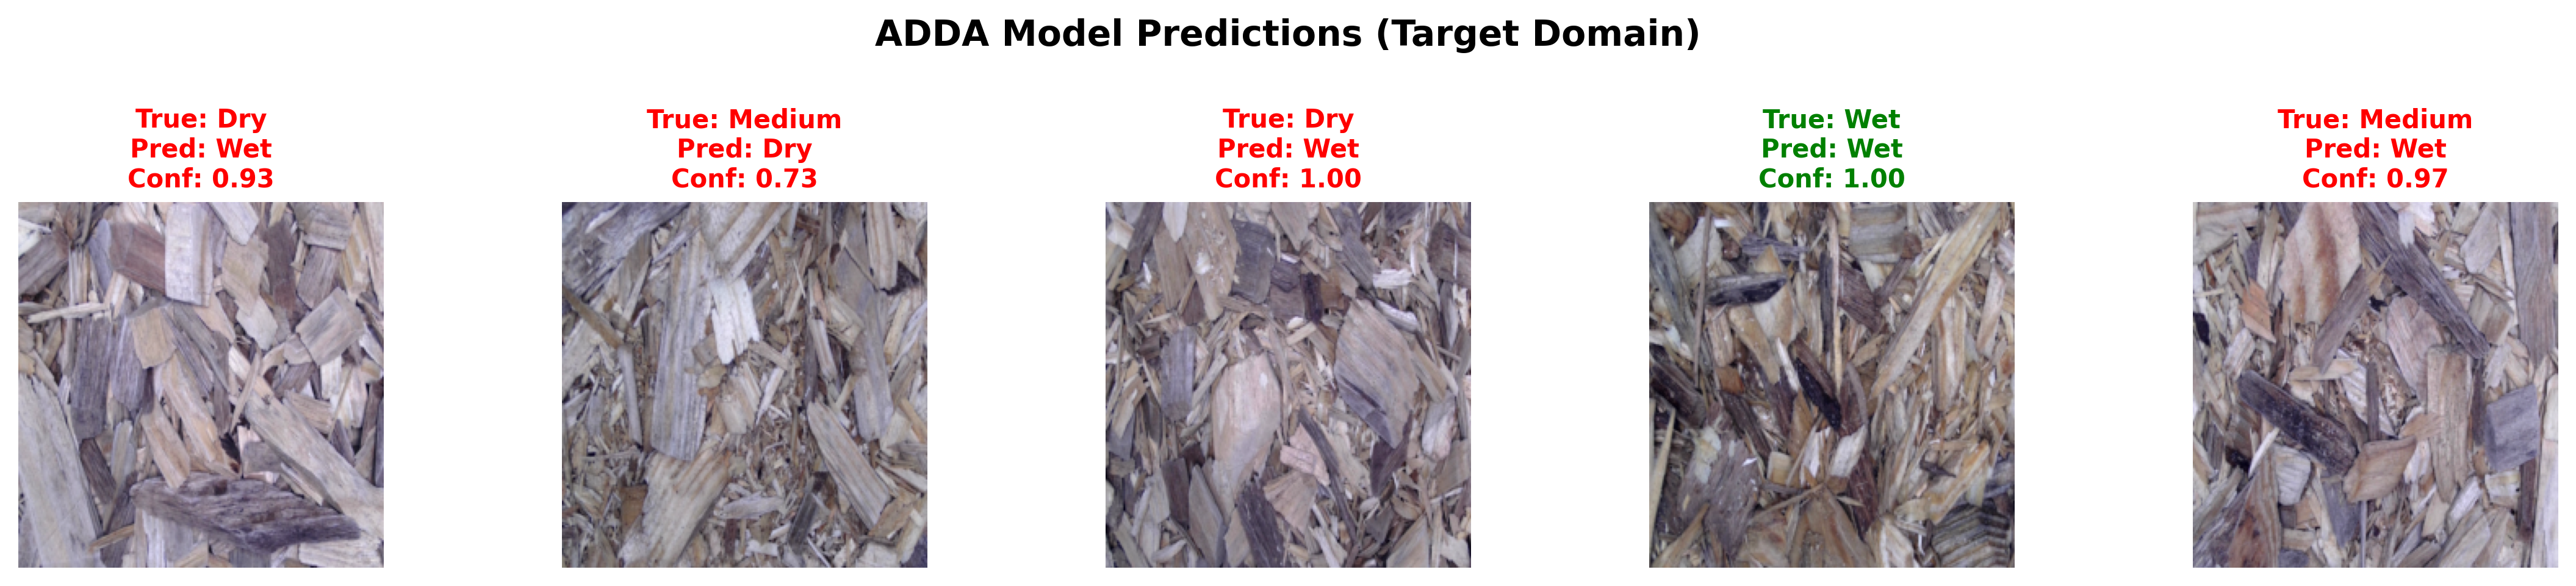

Saved: D:\Woodchip_moisture_content\Adapt_codes\ADDA\ADDA_2_1\target_predictions_grid.jpg

Copying original source domain images...
Saved: D:\Woodchip_moisture_content\Adapt_codes\ADDA\ADDA_2_1\source_samples\1_True_Wet_Pred_Wet_Conf_0.76.jpg
Saved: D:\Woodchip_moisture_content\Adapt_codes\ADDA\ADDA_2_1\source_samples\2_True_Medium_Pred_Medium_Conf_1.00.jpg
Saved: D:\Woodchip_moisture_content\Adapt_codes\ADDA\ADDA_2_1\source_samples\3_True_Dry_Pred_Medium_Conf_1.00.jpg
Saved: D:\Woodchip_moisture_content\Adapt_codes\ADDA\ADDA_2_1\source_samples\4_True_Medium_Pred_Wet_Conf_0.57.jpg
Saved: D:\Woodchip_moisture_content\Adapt_codes\ADDA\ADDA_2_1\source_samples\5_True_Dry_Pred_Dry_Conf_0.92.jpg

Copying original target domain images...
Saved: D:\Woodchip_moisture_content\Adapt_codes\ADDA\ADDA_2_1\target_samples\1_True_Dry_Pred_Wet_Conf_0.93.jpg
Saved: D:\Woodchip_moisture_content\Adapt_codes\ADDA\ADDA_2_1\target_samples\2_True_Medium_Pred_Dry_Conf_0.73.jpg
Saved: D:\Woodchip_moisture_conten

In [5]:
import os
import sys
import shutil
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

sys.path.append(r"D:\Woodchip_moisture_content\Dataset")
from dataset_2_1 import SourceDataset, WoodChipTargetEvalDataset

SAVE_DIR    = r"D:\Woodchip_moisture_content\Adapt_codes\ADDA\ADDA_2_1"
LABEL_NAMES = ['Dry', 'Medium', 'Wet']

# ============================================================
# Load Saved Outputs
# ============================================================
Xs            = np.load(os.path.join(SAVE_DIR, "Xs.npy"))
ys_int        = np.load(os.path.join(SAVE_DIR, "ys_int.npy"))
Xt_eval       = np.load(os.path.join(SAVE_DIR, "Xt_eval.npy"))
yt_int        = np.load(os.path.join(SAVE_DIR, "yt_int.npy"))
ys_val_int    = np.load(os.path.join(SAVE_DIR, "ys_val_int.npy"))
val_preds     = np.load(os.path.join(SAVE_DIR, "val_preds.npy"))
src_probs_vis = np.load(os.path.join(SAVE_DIR, "src_probs_vis.npy"))
src_preds_vis = np.load(os.path.join(SAVE_DIR, "src_preds_vis.npy"))
tgt_probs_vis = np.load(os.path.join(SAVE_DIR, "tgt_probs_vis.npy"))
tgt_preds_vis = np.load(os.path.join(SAVE_DIR, "tgt_preds_vis.npy"))

print("Outputs loaded successfully.")

# ============================================================
# Load Original File Paths
# ============================================================
src_dataset = SourceDataset()
tgt_dataset = WoodChipTargetEvalDataset()

src_paths = [s[0] for s in src_dataset.samples]
tgt_paths = [s[0] for s in tgt_dataset.samples]

# ============================================================
# Confusion Matrix
# ============================================================
def plot_confusion_matrix(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
                linewidths=0.5, ax=ax)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_path = os.path.join(SAVE_DIR, filename)
    plt.savefig(save_path, format='jpg', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

plot_confusion_matrix(yt_int, tgt_preds_vis,
                      'Confusion Matrix — Target Domain (Full)',
                      'confusion_matrix_target_full.jpg')

# ============================================================
# Visualization Grid
# ============================================================
np.random.seed(42)
src_indices = np.random.choice(len(Xs), 5, replace=False)
tgt_indices = np.random.choice(len(Xt_eval), 5, replace=False)

def save_visualization_grid(X, y_true, y_pred, y_probs, indices, title, filename):
    fig, axes = plt.subplots(1, 5, figsize=(15, 3), dpi=300)
    for ax, idx in zip(axes, indices):
        img = X[idx].copy()
        img = (img - img.min()) / (img.max() - img.min())
        ax.imshow(img)
        ax.axis('off')
        pred  = y_pred[idx]
        true  = y_true[idx]
        conf  = y_probs[idx][pred]
        color = 'green' if pred == true else 'red'
        ax.set_title(
            f"True: {LABEL_NAMES[true]}\nPred: {LABEL_NAMES[pred]}\nConf: {conf:.2f}",
            color=color, fontsize=10, fontweight='bold'
        )
    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    save_path = os.path.join(SAVE_DIR, filename)
    plt.savefig(save_path, format='jpg', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

print("\nVisualizing predictions on SOURCE domain samples:")
save_visualization_grid(Xs, ys_int, src_preds_vis, src_probs_vis, src_indices,
                        'ADDA Model Predictions (Source Domain)',
                        'source_predictions_grid.jpg')

print("\nVisualizing predictions on TARGET domain samples:")
save_visualization_grid(Xt_eval, yt_int, tgt_preds_vis, tgt_probs_vis, tgt_indices,
                        'ADDA Model Predictions (Target Domain)',
                        'target_predictions_grid.jpg')

# ============================================================
# Copy Original Images
# ============================================================
src_folder = os.path.join(SAVE_DIR, "source_samples")
tgt_folder = os.path.join(SAVE_DIR, "target_samples")
os.makedirs(src_folder, exist_ok=True)
os.makedirs(tgt_folder, exist_ok=True)

def copy_original_images(paths, y_true, y_pred, y_probs, indices, folder):
    for i, idx in enumerate(indices):
        true_label = LABEL_NAMES[y_true[idx]]
        pred_label = LABEL_NAMES[y_pred[idx]]
        conf       = y_probs[idx][y_pred[idx]]
        ext        = os.path.splitext(paths[idx])[1]
        filename   = f"{i+1}_True_{true_label}_Pred_{pred_label}_Conf_{conf:.2f}{ext}"
        save_path  = os.path.join(folder, filename)
        shutil.copy2(paths[idx], save_path)
        print(f"Saved: {save_path}")

print("\nCopying original source domain images...")
copy_original_images(src_paths, ys_int, src_preds_vis, src_probs_vis, src_indices, src_folder)

print("\nCopying original target domain images...")
copy_original_images(tgt_paths, yt_int, tgt_preds_vis, tgt_probs_vis, tgt_indices, tgt_folder)

print("\nDone! Check folders:")
print(f"  Source: {src_folder}")
print(f"  Target: {tgt_folder}")

# ============================================================
# Prediction Summary
# ============================================================
print("\n" + "="*60)
print("PREDICTION SUMMARY")
print("="*60)
src_n_correct = int(np.sum(src_preds_vis == ys_int))
tgt_n_correct = int(np.sum(tgt_preds_vis == yt_int))
print(f"Source Domain: {src_n_correct}/{len(ys_int)} correct ({accuracy_score(ys_int, src_preds_vis):.1%})")
print(f"Target Domain: {tgt_n_correct}/{len(yt_int)} correct ({accuracy_score(yt_int, tgt_preds_vis):.1%})")
print("="*60)